# This notebook serves as an example to show how we can load the train/validation/test data directly in a pytorch dataloader. 

# Warning: I am not sure if this is an efficient way to load the data.


# Library imports

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Global Variables

In [3]:
GLOBAL_PATH = '/kaggle/input/google-research-identify-contrails-reduce-global-warming'
BATCH_SIZE = 128

**Variables for SI Pre-Processing**

In [4]:
limits_spectralIndex = {(8, 9): (-2.0073962, 1.2556516),
        (8, 10): (-1.2914455, 1.9591796),
        (8, 11): (-0.65337217, 1.1425757),
        (8, 12): (-0.4293038, 0.5412206),
        (8, 13): (-0.3719291, 0.7068149),
        (8, 14): (-0.32991663, 0.5749295),
        (8, 15): (-0.2951218, 0.47614375),
        (8, 16): (-0.27196515, 0.32695884),
        (9, 10): (-2.47288, 5.0891347),
        (9, 11): (-0.7054117, 1.5090419),
        (9, 12): (-0.31053233, 0.6374393),
        (9, 13): (-0.34346375, 0.7703995),
        (9, 14): (-0.28906363, 0.6275368),
        (9, 15): (-0.24612188, 0.49756303),
        (9, 16): (-0.20720091, 0.3013589),
        (10, 11): (-1.8315057, 1.7731701),
        (10, 12): (-1.0108625, 0.67475146),
        (10, 13): (-0.73298323, 0.7571506),
        (10, 14): (-0.60375404, 0.58967346),
        (10, 15): (-0.50824136, 0.45918718),
        (10, 16): (-0.45957223, 0.3249839),
        (11, 12): (-1.5498391, 1.1068077),
        (11, 13): (-0.37653866, 0.43000376),
        (11, 14): (-0.57611704, 0.29362467),
        (11, 15): (-0.5367903, 0.19310474),
        (11, 16): (-0.4271444, 0.1274666),
        (12, 13): (-2.0401301, 3.0744278),
        (12, 14): (-0.9623841, 1.4088525),
        (12, 15): (-0.7368909, 0.82770354),
        (12, 16): (-0.525251, 0.4200794),
        (13, 14): (-1.8499428, 0.17252406),
        (13, 15): (-1.0927216, 0.20189151),
        (13, 16): (-0.72561383, 0.07278631),
        (14, 15): (-0.67102945, 0.44037148),
        (14, 16): (-0.8847657, 0.12533462),
        (15, 16): (-1.5200828, 0.3035623)}

# Spectral Index (SI) Method Pre-Processing

**Base Settings**

In [5]:
baseSettings_SpectralIndex = {
    "BASE_DIR": GLOBAL_PATH +'/train',
    "example_record_id": '1704010292581573769',
    "lambda": np.array([0.,0.47,0.64,0.86,1.37,1.6,2.2,3.9,6.2,6.9,7.3,8.4,9.6,10.3,11.2,12.3,13.3]),
    "N_TIMES_BEFORE": 4,
    "limits_spectralIndex": limits_spectralIndex
}

example_record_id = baseSettings_SpectralIndex["example_record_id"]

**Functions for SI Pre-Processing**

In [6]:
def get_human_mask(record_id = example_record_id, **kwargs):
    # access base dir
    BASE_DIR = kwargs["BASE_DIR"]
    
    # load ground truth mask
    with open(os.path.join(BASE_DIR, record_id, 'human_pixel_masks.npy'), 'rb') as f:
        human_pixel_mask = np.load(f)
    
    # return human pixel mask as numpy array
    return human_pixel_mask


def load_band(band_number,record_id = example_record_id, **kwargs):
    # access base dir
    BASE_DIR = kwargs["BASE_DIR"]
    
    # load band
    with open(os.path.join(BASE_DIR, record_id, f'band_{band_number:02}.npy'), 'rb') as f:
        band_i = np.load(f)
    
    # return image sequence of i-th band as numpy array
    return band_i


def base_spectral_index(band_numberA, band_numberB, record_id = example_record_id, limit_frame = True, **kwargs):
    # get wavelengths
    lam   = kwargs["lambda"]
    
    # individual bands
    bandA = load_band(band_numberA,record_id=record_id, **kwargs)
    bandB = load_band(band_numberB,record_id=record_id, **kwargs)

    # calculate spectral index
    spectral_index = np.log(bandA/bandB)/ np.log(lam[band_numberA]/lam[band_numberB])
    
    if limit_frame:
        # get just one frame of interest
        spectral_index = spectral_index[..., kwargs["N_TIMES_BEFORE"]]
    
    # return the spectral index of band A wrt band B
    return spectral_index


def normalize_range(spectral_map, band_numberA, band_numberB, **kwargs):
    """Maps spectral_map to the range [0, 1]."""
    # get bounds
    s_min, s_max = kwargs["limits_spectralIndex"][(min(band_numberA, band_numberB),max(band_numberA, band_numberB))]
    
    # normalize
    return (spectral_map - s_min) / (s_max - s_min)


def spektral_index(band_numberA, band_numberB, record_id = example_record_id, limit_frame = False, **kwargs):
    # get spectral index map
    s_map = base_spectral_index(band_numberA, band_numberB, record_id = record_id, limit_frame = limit_frame, **kwargs)
    
    # normalize it
    s_map = normalize_range(s_map, band_numberA, band_numberB, **kwargs)
    
    # clip it
    s_map = np.clip(s_map, 0, 1)

    return s_map


def load_spektral_index(record_id = example_record_id, band_numberA = 13, band_numberB= 14, limit_frame = False, **kwargs):
    # get spectral index map
    s_map = base_spectral_index(band_numberA, band_numberB, record_id = record_id, limit_frame = limit_frame, **kwargs)
    
    # normalize it
    s_map = normalize_range(s_map, band_numberA, band_numberB, **kwargs)
    
    # clip it
    s_map = np.clip(s_map, 0, 1)
    
    # get mask
    mask = get_human_mask(record_id = record_id, **kwargs)
    
    return s_map, mask

**Class for SI Dataset**

In [7]:
class ContrailDataset_SI(Dataset):
    def __init__(self, base_dir, data_type='train', transform=None):
        assert data_type in ['train', 'validation', 'test'], \
            "'data_type' should be one of 'train', 'validation', or 'test'"

        self.base_dir = base_dir
        self.data_type = data_type
        self.transform = transform
        self.record = os.listdir(self.base_dir +'/'+ self.data_type)

    def __len__(self):
        return len(self.record)

    def __getitem__(self, idx):
        record_id = self.record[idx]
        record_dir = os.path.join(self.base_dir, self.data_type, record_id)
        
        spectralIndex_map, pixel_masks = load_spektral_index(record_id = record_id, 
                            band_numberA = 13, 
                            band_numberB= 14, 
                            limit_frame = False, 
                            **baseSettings_SpectralIndex)
        

        # If the data type is 'train' or 'validation', load the masks
        if self.data_type not in ['train', 'validation']:
            pixel_masks = None  # No masks for 'test' data
        
        # shapes: (256,256,8) and (256,256)
        sample = {'bands': spectralIndex_map, 'masks': pixel_masks}

        if self.transform:
            sample = self.transform(sample)

        return sample

**Function for SI DataLoader**

In [8]:
def get_dataloader_SI(base_dir, data_type, batch_size, transform=None):
    dataset = ContrailDataset_SI(base_dir, data_type=data_type, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    return dataloader

# Delta Method Pre-processing

**Functions for Delta Pre-Processing**

In [9]:
def collate_fn(batch):
    """Collate function to use with DataLoader for batching"""
    # Here we assume that each element in batch is a dict {'bands': bands, 'masks': masks}
    bands = torch.stack([torch.from_numpy(item['bands']) for item in batch])
    
    # Check if masks are present
    if batch[0]['masks'] is not None:
        masks = torch.stack([torch.from_numpy(item['masks']) for item in batch])
    else:
        masks = None

    return bands, masks

**Class for Delta Dataset**

In [49]:
class ContrailDataset(Dataset):
    def __init__(self, base_dir, data_type='train', transform=None):
        assert data_type in ['train', 'validation', 'test'], \
            "'data_type' should be one of 'train', 'validation', or 'test'"

        self.base_dir = base_dir
        self.data_type = data_type
        self.transform = transform
        self.record = os.listdir(self.base_dir +'/'+ self.data_type)

    def __len__(self):
        return len(self.record)

    def __getitem__(self, idx):
        record_id = self.record[idx]
        record_dir = os.path.join(self.base_dir, self.data_type, record_id)

        # Load the necessary .npy files
        bands_data = []
        for i in range(8, 17):
            band_file = os.path.join(record_dir, f'band_{str(i).zfill(2)}.npy')
            band_data = np.load(band_file)
            bands_data.append(band_data)

        # Stack band data along the channel axis
        bands_data = np.stack(bands_data, axis=-1)

        
        # If the data type is 'train' or 'validation', load the masks
        if self.data_type in ['train', 'validation']:
            pixel_masks_file = os.path.join(record_dir, 'human_pixel_masks.npy')
            pixel_masks = np.load(pixel_masks_file)
        else:
            pixel_masks = None  # No masks for 'test' data
        
        """   
        # Assuming your .npy data is named 'data'
        data = bands_data

        # Load the necessary bands for NDVI calculation (you need the Near-Infrared and Red bands)

        for i in range(8):
            for j in range(8):
                nir_band = data[3, :, :, i, 0]
                red_band = data[3, :, :, j, 0]

        # Calculate the NDVI
        ndvi = (nir_band - red_band) / (nir_band + red_band)

        sample = {'bands': ndvi, 'masks': pixel_masks}
        
        # """
        
        sample = {'bands': bands_data, 'masks': pixel_masks}

        if self.transform:
            sample = self.transform(sample)

        return sample

**Function for Delta DataLoader**

In [50]:
def get_dataloader(base_dir, data_type, batch_size, transform=None):
    dataset = ContrailDataset(base_dir, data_type=data_type, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collate_fn)

    return dataloader

# Instantiating Dataloaders

**Del Dataloader**

In [51]:
#Instantiate the dataloader by defining the global path and the 
train_dataloader_Del = get_dataloader(GLOBAL_PATH, 'train', batch_size=BATCH_SIZE)
validation_dataloader_Del = get_dataloader(GLOBAL_PATH, 'validation', batch_size=BATCH_SIZE)
#test_dataloader = get_dataloader(GLOBAL_PATH, 'test', batch_size=16)

**SI Dataloader**

In [13]:
#Instantiate the dataloader by defining the global path and the 
train_dataloader_SI = get_dataloader_SI(GLOBAL_PATH, 'train', batch_size=BATCH_SIZE)
validation_dataloader_SI = get_dataloader_SI(GLOBAL_PATH, 'validation', batch_size=BATCH_SIZE)
#test_dataloader = get_dataloader(GLOBAL_PATH, 'test', batch_size=16)

# Check shapes

**SI**

In [14]:
# Get the first batch
bands_SI, masks_SI = next(iter(train_dataloader_SI))
print(bands_SI.shape)  # Batch size, H, W, Timeframe
print(masks_SI.shape)

torch.Size([128, 256, 256, 8])
torch.Size([128, 256, 256, 1])


**Delta**

In [52]:
bands_Del, masks_Del = next(iter(train_dataloader_Del))
print(bands_Del.shape)  # Batch size, H, W, Timeframe, Bands
print(masks_Del.shape)

torch.Size([128, 256, 256, 8, 9])
torch.Size([128, 256, 256, 1])


# Plotting

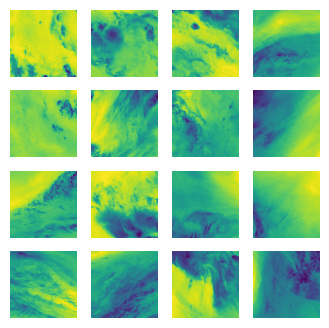

In [16]:
# Plot the first band and first time frame for all 16 samples
plt.figure(figsize=(4, 4))

# Loop through all bands and plot them
for i in range(16):
    # Extract the first band and first time frame
    band = bands_Del[i, :, :, 0, 0]

    # Convert tensor to numpy array if necessary
    if isinstance(band, torch.Tensor):
        band = band.cpu().numpy()

    # Create a subplot for each band
    plt.subplot(4, 4, i + 1)
    plt.imshow(band)
    plt.axis('off')

# Show the plot
plt.show()

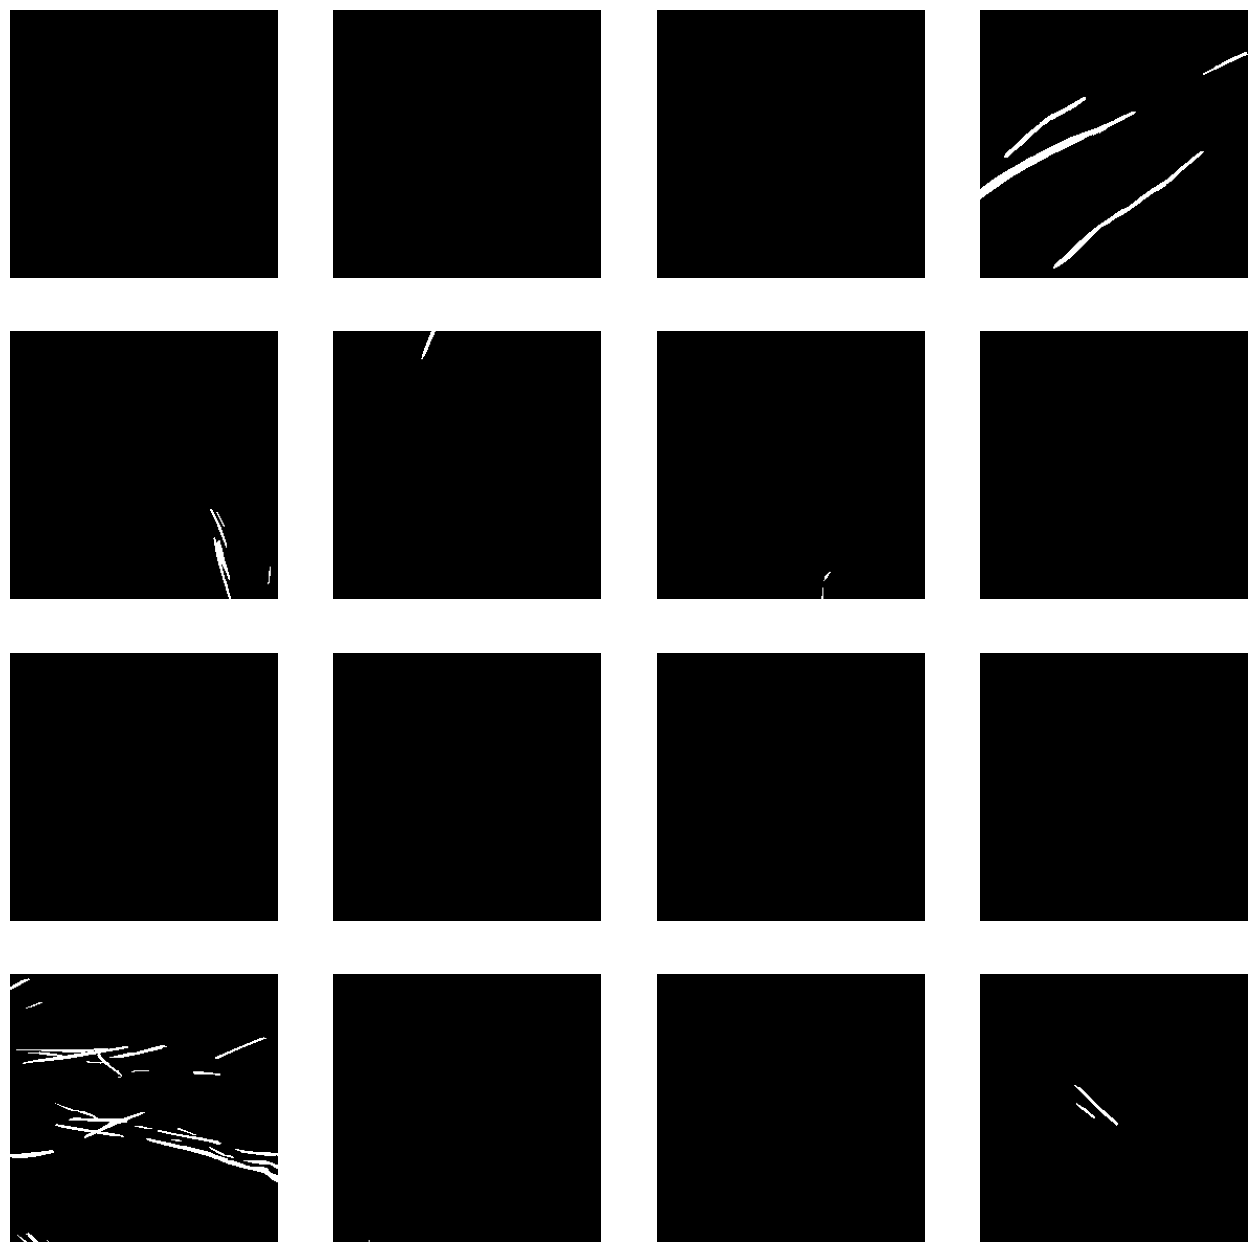

In [18]:
#Plot the ground truth masks for all 16 samples:
plt.figure(figsize=(16, 16))

# Loop through all masks and plot them
for i in range(16):
    mask = masks_Del[i].numpy()

    # Convert tensor to numpy array if necessary

    # Create a subplot for each mask
    plt.subplot(4, 4, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

# Show the plot
plt.show()

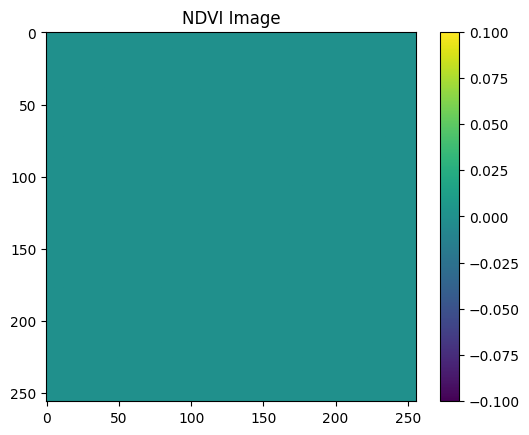

In [19]:
# Assuming your .npy data is named 'data'
data = bands_Del

# Load the necessary bands for NDVI calculation (you need the Near-Infrared and Red bands)
for i in range (0,8):
    for j in range (0,8):

        nir_band = data[3,:, :, i,0]
        red_band = data[3,:, :, j,0]

# Calculate the NDVI
        ndvi = (nir_band - red_band) / (nir_band + red_band)

# Visualize the NDVI (optional)
plt.imshow(ndvi, cmap='viridis')
plt.colorbar()
plt.title('NDVI Image')
plt.show()

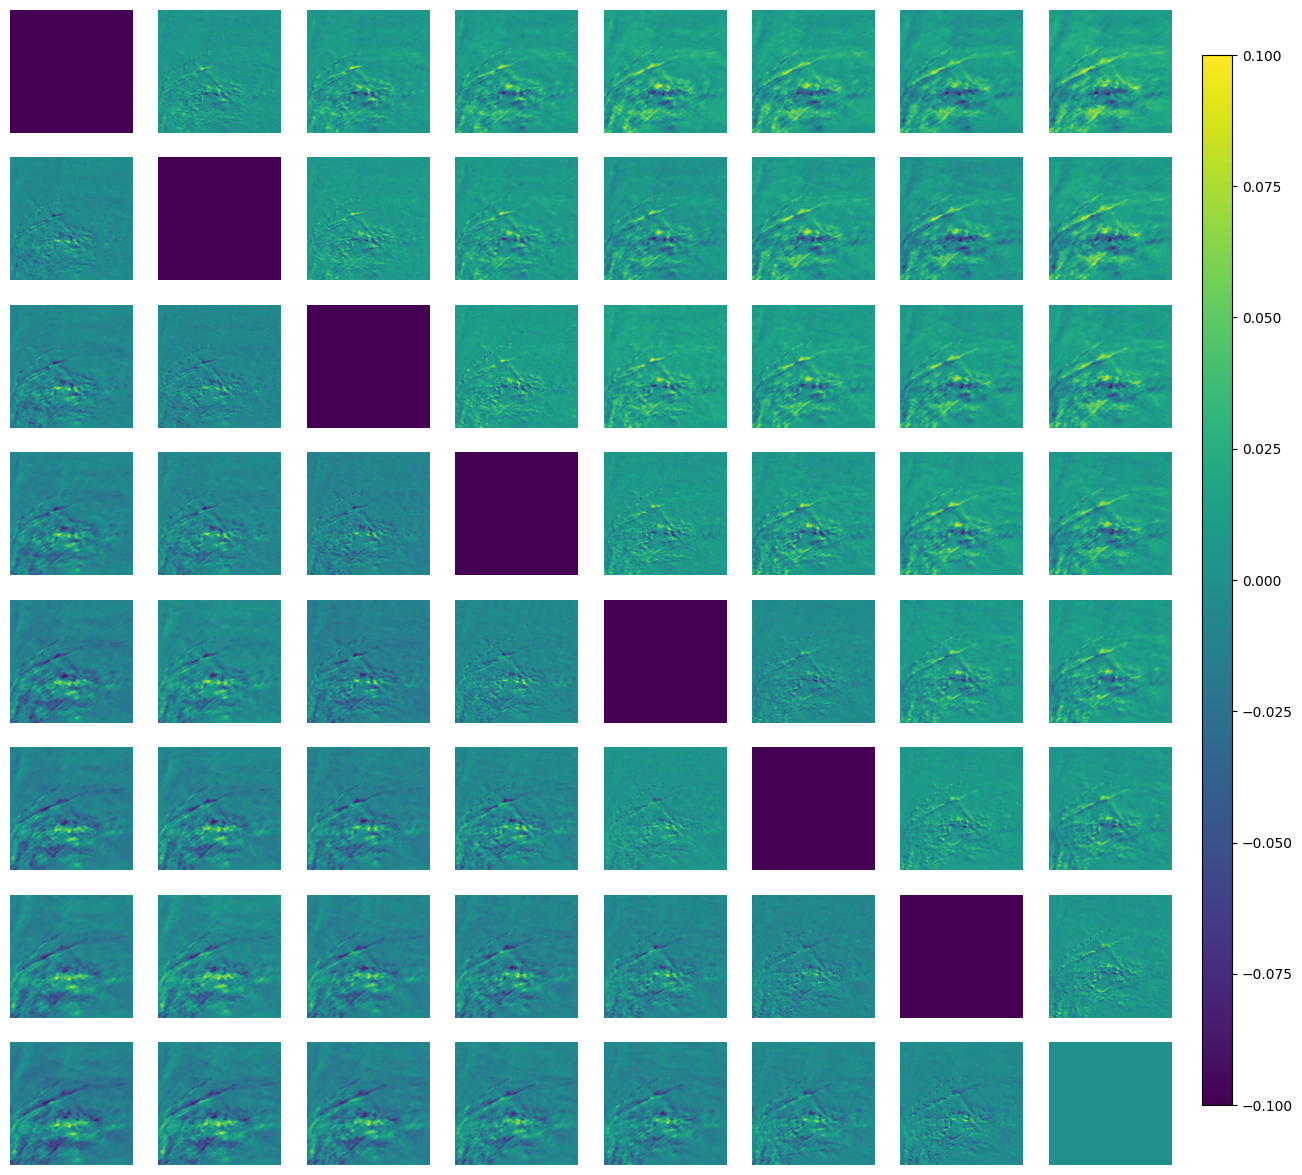

In [20]:
# Assuming your .npy data is named 'data'
data = bands_Del

# Load the necessary bands for NDVI calculation (you need the Near-Infrared and Red bands)
fig, axs = plt.subplots(8, 8, figsize=(15, 15))

for i in range(8):
    for j in range(8):
        nir_band = data[3, :, :, i, 0]
        red_band = data[3, :, :, j, 0]

        # Calculate the NDVI
        ndvi = (nir_band - red_band) / (nir_band + red_band)

        # Plot the NDVI image on the corresponding subplot
        ax = axs[i, j]
        im = ax.imshow(ndvi, cmap='viridis')
        ax.axis('off')

# Add a common colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

# Nothing changed beyond this point in v04

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import zipfile

# Assuming your .npy data is named 'data'
data = bands

# Create an output directory to save the images
output_dir = '/kaggle/working/images'
os.makedirs(output_dir, exist_ok=True)

# Load the necessary bands for NDVI calculation (you need the Near-Infrared and Red bands)
for i in range(8):
    for j in range(8):
        nir_band = data[3, :, :, i, 0]
        red_band = data[3, :, :, j, 0]

        # Calculate the NDVI
        ndvi = (nir_band - red_band) / (nir_band + red_band)

        # Plot the NDVI image on the corresponding subplot
        plt.imshow(ndvi, cmap='viridis')
        plt.axis('off')

        # Save the image to the output directory with a unique filename
        plt.savefig(os.path.join(output_dir, f'ndvi_band{i}_band{j}.png'))

        # Close the figure to free up resources
        plt.close()

# Compress the output directory into a ZIP file
zip_filename = '/kaggle/working/images.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), output_dir))

print("All NDVI images saved and compressed successfully.")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Assuming your .npy data is named 'data'
data = bands

# Create a list to store the filenames of the individual images
image_filenames = []

# Load the necessary bands for NDVI calculation (you need the Near-Infrared and Red bands)
for i in range(8):
    for j in range(8):
        nir_band = data[5, :, :, i, 0]
        red_band = data[5, :, :, j, 0]

        # Calculate the NDVI
        ndvi = (nir_band - red_band) / (nir_band + red_band)

        # Plot the NDVI image on the corresponding subplot
        plt.imshow(ndvi, cmap='viridis')
        plt.axis('off')

        # Save the individual NDVI image as a PNG file
        image_filename = f'/kaggle/working/ndvi_band{i}_band{j}.png'
        plt.savefig(image_filename)

        # Append the image filename to the list
        image_filenames.append(image_filename)

        # Close the figure to free up resources
        plt.close()

# Determine the number of columns in the mosaic
num_columns = 8

# Create a list to store the images
image_list = []

# Open and append the individual images to the list
for image_filename in image_filenames:
    img = Image.open(image_filename)
    image_list.append(img)

# Combine the images horizontally into one big image
combined_image = Image.new('RGB', (image_list[0].width * num_columns, image_list[0].height * num_columns))
for i, img in enumerate(image_list):
    combined_image.paste(img, (img.width * (i % num_columns), img.height * (i // num_columns)))

# Save the combined image
combined_image.save('/kaggle/working/combined_ndvi_image.png')

# Delete the individual image files to clean up the directory
for image_filename in image_filenames:
    os.remove(image_filename)

print("Combined NDVI image saved successfully.")
